In [9]:
# 载入 PyTomoATT 模块
# 文档：https://tomoatt.github.io/PyTomoATT/index.html

import pytomoatt as pta

import numpy as np

In [10]:
import os
os.makedirs('figs', exist_ok=True)

# 模型画图

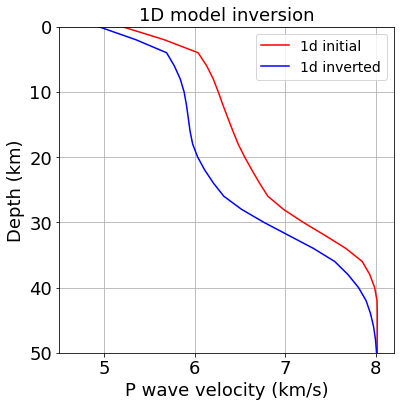

In [11]:
par_file = "3_input_params/input_params_step1_1D_inv.yaml"

fname_init  = "2_models/model_1d_crust1.0_N31_61_31.h5"
fname_inv   = "OUTPUT_FILES/OUTPUT_FILES_step1_1D_inv/final_model.h5"

att_model_init = pta.ATTModel.read(fname_init,par_file)
all_dep = np.array(att_model_init.depths)
vel_init = np.array(att_model_init.vel[:, 0, 0])

att_model_inv = pta.ATTModel.read(fname_inv,par_file)
vel_inv = np.array(att_model_inv.vel[:, 0, 0])


# 层状模型画图
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6,6))
gridspace = GridSpec(6,6,figure = fig)
ax2 = fig.add_subplot(gridspace[0:6, 0:6])


ax2.plot(vel_init,all_dep,'r-',label="1d initial")
ax2.plot(vel_inv,all_dep,'b-',label="1d inverted")
ax2.legend(fontsize = 14)
ax2.tick_params(axis='x',labelsize=18)
ax2.tick_params(axis='y',labelsize=18)
ax2.set_ylabel('Depth (km)',fontsize=18)
ax2.set_xlabel('P wave velocity (km/s)',fontsize=18)
ax2.set_ylim([0,50])
ax2.set_xlim([4.5,8.2])
ax2.invert_yaxis()
ax2.set_title('1D model inversion',fontsize=18)
ax2.grid()

fig.savefig("figs/Step3_id_model_inv.png",dpi=300,bbox_inches='tight',facecolor='w',edgecolor='w')

# 走时残差画图

In [12]:
# 读取观测走时数据
sr_obs = pta.SrcRec.read("1_src_rec_files/src_rec_file.dat")
# 可以查看走时数据
# print(sr_obs.rec_points)      # 绝对走时
# print(sr_obs.rec_points_cs)   # 共源差分到时
# print(sr_obs.rec_points_cr)   # 共台差分到时

# 读取初始模型理论走时
sr_ini = pta.SrcRec.read("OUTPUT_FILES/OUTPUT_FILES_step1_1D_inv/src_rec_file_step_0000.dat")

# 读取反演模型理论走时
sr_inv = pta.SrcRec.read("OUTPUT_FILES/OUTPUT_FILES_step1_1D_inv/src_rec_file_step_0014.dat")

residual for  initial model  model is:  mean:  -0.6427131466880573 sd:  0.7896697515854072
residual for  inv model  model is:  mean:  0.01324742172571883 sd:  0.7598074471423951


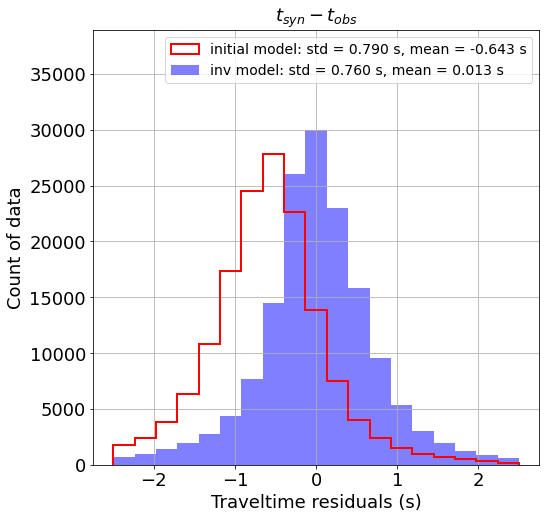

In [13]:
# 画直方图

# 计算走时残差
time_obs                = np.array(sr_obs.rec_points.tt)
time_init_syn           = np.array(sr_ini.rec_points.tt)
time_inv_syn            = np.array(sr_inv.rec_points.tt)
error_init = time_init_syn - time_obs
error_final = time_inv_syn - time_obs


import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

range_l = -2.5
range_r = 2.5
Nbar = 20

bins=np.linspace(range_l,range_r,Nbar)

tag1 = "initial model"
tag2 = "inv model"

hist_init,  _, _ = ax.hist(error_init,bins=bins,histtype='step', edgecolor = "red", linewidth = 2,
        label = "%s: std = %5.3f s, mean = %5.3f s"%(tag1,np.std(error_init),np.mean(error_init)))

hist_final, _, _ = ax.hist(error_final,bins=bins,alpha = 0.5, color = "blue",
        label = "%s: std = %5.3f s, mean = %5.3f s"%(tag2,np.std(error_final),np.mean(error_final)))

print("residual for ",tag1," model is: ","mean: ",np.mean(error_init),"sd: ",np.std(error_init))
print("residual for ",tag2," model is: ","mean: ",np.mean(error_final),"sd: ",np.std(error_final))
ax.legend(fontsize=14)

ax.set_xlim(range_l - abs(range_l)*0.1,range_r + abs(range_r)*0.1)
ax.set_ylim(0,1.3*max(max(hist_init),max(hist_final)))

ax.tick_params(axis='x',labelsize=18)
ax.tick_params(axis='y',labelsize=18)
ax.set_ylabel('Count of data',fontsize=18)
ax.set_xlabel('Traveltime residuals (s)',fontsize=18)
ax.set_title("$t_{syn} - t_{obs}$",fontsize=18)
ax.grid()

plt.savefig("figs/Step3_residual.png",dpi=300, bbox_inches='tight', edgecolor='w', facecolor='w' )
plt.show()

# 画目标函数下降

In [14]:
# 读取目标函数文件的函数
def read_objective_function_file(fname):

    full_curve = []
    location_curve = []
    model_curve = []

    with open(fname) as f:
        for i,line in enumerate(f):
            tmp = line.split(',')
            if (tmp[0].__contains__("#")):
                continue

            iter        = int(tmp[0])
            tag         = tmp[1]
            obj         = float(tmp[2])

            print("iter: ",iter," tag: ",tag," obj: ",obj)
            full_curve.append(obj)
            if tag.__contains__("relocation"):
                location_curve.append(obj)
            if tag.__contains__("model") or tag.__contains__("1d inversion") :
                model_curve.append(obj)

    return full_curve, location_curve, model_curve

iter:  0  tag:   1d inversion  obj:  158960.0
iter:  1  tag:   1d inversion  obj:  140584.0
iter:  2  tag:   1d inversion  obj:  122172.0
iter:  3  tag:   1d inversion  obj:  105391.0
iter:  4  tag:   1d inversion  obj:  93045.3
iter:  5  tag:   1d inversion  obj:  89728.7
iter:  6  tag:   1d inversion  obj:  91326.2
iter:  7  tag:   1d inversion  obj:  89484.2
iter:  8  tag:   1d inversion  obj:  88674.8
iter:  9  tag:   1d inversion  obj:  88652.7
iter:  10  tag:   1d inversion  obj:  88572.4
iter:  11  tag:   1d inversion  obj:  88757.2
iter:  12  tag:   1d inversion  obj:  88422.6
iter:  13  tag:   1d inversion  obj:  88357.2
iter:  14  tag:   1d inversion  obj:  88550.7


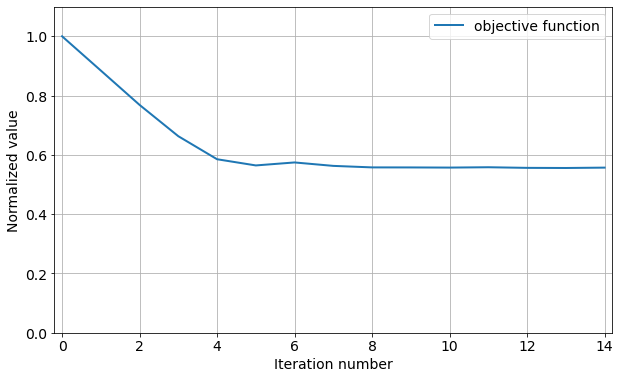

In [15]:
fname = "OUTPUT_FILES/OUTPUT_FILES_step1_1D_inv/objective_function.txt"
full_curve, location_curve, model_curve = read_objective_function_file(fname)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
ax = plt.subplot(1, 1, 1)

ax.plot(model_curve/np.max(model_curve), label='objective function', linewidth=2)
ax.set_xlim([-0.2, len(model_curve)-0.8])
ax.set_ylim([0, 1.1])
ax.grid()
ax.set_xlabel('Iteration number',fontsize=14)
ax.set_ylabel('Normalized value',fontsize=14)
ax.tick_params(axis='x', labelsize=14)  
ax.tick_params(axis='y', labelsize=14) 
ax.legend(fontsize=14)

plt.savefig('figs/Step3_objective_function_reduction.png', dpi=300, bbox_inches='tight', edgecolor='w', facecolor='w')